# Headcount Attrition - Survival Analysis

**Objective:** two questions, both answered from one model — **forecasting**: rank current employees by risk of resignation; **inference**: identify which factors actually drive that risk, and by how much.
**Method:** Cox Proportional Hazards only. An earlier version of this notebook also ran a separate classifier (Logistic Regression / Random Forest / Gradient Boosting) to answer "who" -- dropped because Cox PH already answers both questions on its own: `predict_partial_hazard` ranks who's at risk (forecasting), and the fitted hazard ratios explain why (inference), without needing a second model or its own preprocessing/tuning/evaluation stack.

In [1]:
import os
import re
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

CONFIG = {
    "DATA_PATH": "../data/IBM-HR-Employee-Attrition.csv",
    "RESULT_DIR": "../result/",
    "RANDOM_STATE": 42,
}
RANDOM_STATE = CONFIG["RANDOM_STATE"]

for folder in ["figures", "slides"]:
    Path(os.path.join(CONFIG["RESULT_DIR"], folder)).mkdir(parents=True, exist_ok=True)

FIG_DIR = os.path.join(CONFIG["RESULT_DIR"], "figures")
SLD_DIR = os.path.join(CONFIG["RESULT_DIR"], "slides")

## STEP 01 - Load Data

In [2]:
def clean_feature_label(name):
    name = name.replace('_', ' ')
    name = re.sub(r'([a-z])([A-Z])', r'\1 \2', name)
    return name.replace(' Yes', ' (Yes)').replace(' No', ' (No)').strip().title()

df = pd.read_csv(CONFIG["DATA_PATH"])
EMPLOYEE_IDS = df["EmployeeNumber"].copy()

print(f"Dataset: {df.shape[0]} employees, {df.shape[1]} columns")
print(f"Attrition rate: {(df['Attrition']=='Yes').mean():.1%} "
      f"({(df['Attrition']=='Yes').sum()} of {len(df)} employees left)")

Dataset: 1470 employees, 35 columns
Attrition rate: 16.1% (237 of 1470 employees left)


## STEP 02 - Exploratory Data Analysis

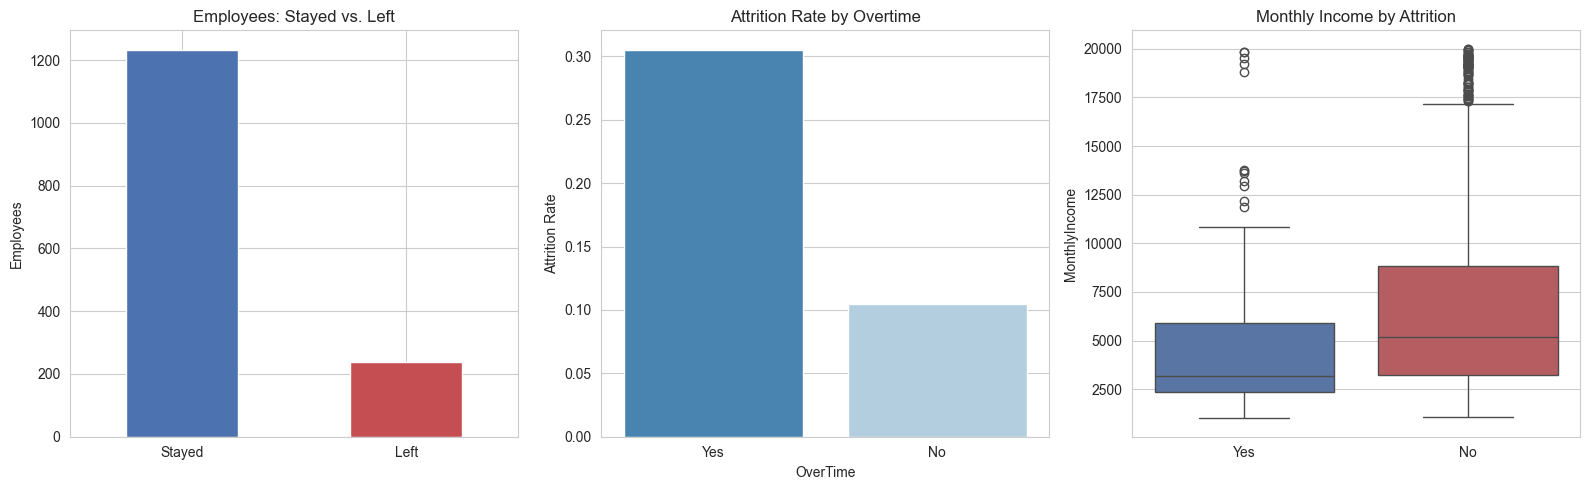

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df["Attrition"].value_counts().rename({"No": "Stayed", "Yes": "Left"}).plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"]
)
axes[0].set_title("Employees: Stayed vs. Left")
axes[0].set_xlabel("")
axes[0].set_ylabel("Employees")
axes[0].tick_params(axis='x', rotation=0)

sns.barplot(x="OverTime", y=(df["Attrition"] == "Yes").astype(int), data=df, ax=axes[1],
            hue="OverTime", palette="Blues_r", legend=False, errorbar=None)
axes[1].set_title("Attrition Rate by Overtime")
axes[1].set_ylabel("Attrition Rate")

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df, ax=axes[2],
            hue="Attrition", palette=["#4C72B0", "#C44E52"], legend=False)
axes[2].set_title("Monthly Income by Attrition")
axes[2].set_xlabel("")

plt.tight_layout()
eda_img_path = os.path.join(FIG_DIR, "eda_overview.png")
plt.savefig(eda_img_path, dpi=300)
plt.show()

## STEP 03 - Prepare Survival Data

Tenure (`YearsAtCompany`) is the duration; leaving is the event, still-employed is right-censored. Covariates are a hand-picked subset, not every column in the dataset -- Cox PH degrades with too many (especially dummy-heavy) covariates, so this keeps only factors with a plausible causal story on attrition, verified below via the assumption check.

In [4]:
SURVIVAL_COVARIATES = [
    "OverTime", "JobLevel", "MonthlyIncome", "JobSatisfaction", "WorkLifeBalance",
    "YearsSinceLastPromotion", "DistanceFromHome", "StockOptionLevel",
    "NumCompaniesWorked", "Age", "MaritalStatus",
]

surv_df = df[["YearsAtCompany", "Attrition"] + SURVIVAL_COVARIATES].copy()
surv_df["event"] = (surv_df["Attrition"] == "Yes").astype(int)
surv_df["duration"] = surv_df["YearsAtCompany"].clip(lower=0.5)
surv_df = surv_df.drop(columns=["Attrition", "YearsAtCompany"])

surv_df = pd.get_dummies(surv_df, columns=["OverTime", "MaritalStatus"], drop_first=True)
surv_df.columns = [c if c in ("duration", "event") else clean_feature_label(c) for c in surv_df.columns]
surv_df = surv_df.astype(float)
surv_df.head()

,Job Level,Monthly Income,Job Satisfaction,Work Life Balance,Years Since Last Promotion,Distance From Home,Stock Option Level,Num Companies Worked,Age,event,duration,Over Time (Yes),Marital Status Married,Marital Status Single
0,2.0,5993.0,4.0,1.0,0.0,1.0,0.0,8.0,41.0,1.0,6.0,1.0,0.0,1.0
1,2.0,5130.0,2.0,3.0,1.0,8.0,1.0,1.0,49.0,0.0,10.0,0.0,1.0,0.0
2,1.0,2090.0,3.0,3.0,0.0,2.0,0.0,6.0,37.0,1.0,0.5,1.0,0.0,1.0
3,1.0,2909.0,3.0,3.0,3.0,3.0,0.0,1.0,33.0,0.0,8.0,1.0,1.0,0.0
4,1.0,3468.0,2.0,3.0,2.0,2.0,1.0,9.0,27.0,0.0,2.0,0.0,1.0,0.0


## STEP 04 - Validate: Fit on Train, Score on Held-Out Test

`penalizer=0.1` adds a small Ridge-style penalty -- Cox PH can fail to converge or overfit when covariates are correlated (e.g. the marital-status dummies), and a small penalty stabilizes that without materially changing the hazard ratios. Concordance index is on the same 0.5 (random) to 1.0 (perfect ranking) scale as ROC-AUC.

In [5]:
surv_train, surv_test = train_test_split(
    surv_df, test_size=0.2, random_state=RANDOM_STATE, stratify=surv_df["event"]
)

cph_val = CoxPHFitter(penalizer=0.1)
cph_val.fit(surv_train, duration_col="duration", event_col="event")

test_cindex = concordance_index(
    surv_test["duration"], -cph_val.predict_partial_hazard(surv_test), surv_test["event"]
)
print(f"Train concordance index: {cph_val.concordance_index_:.3f}")
print(f"Test concordance index : {test_cindex:.3f}")

Train concordance index: 0.849
Test concordance index : 0.846


## STEP 05 - Check the Proportional Hazards Assumption

Cox PH assumes each covariate's effect on hazard is constant over time. This test flags any covariate where that assumption looks violated -- worth knowing before trusting the hazard ratios in the next step.

In [6]:
cph_val.check_assumptions(surv_train, p_value_threshold=0.05, show_plots=False)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Years Since Last Promotion' failed the non-proportional test: p-value is 0.0007.

   Advice 1: the functional form of the variable 'Years Since Last Promotion' might be incorrect.
That is, there may be non-linear terms missing. The proportional hazard test used is very sensitive
to incorrect functional forms. See documentation in link [D] below on how to specify a functional
form.

   Advice 2: try binning the variable 'Years Since Last Promotion' using pd.cut, and then specify it
in `strata=['Years Since Last Promotion', ...]` in the call in `.fit`. See documentation in link [B]
below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs

[]

## STEP 06 - Refit on the Full Population

STEP 04 validated the *method* on a held-out split. The model actually used for ranking today's employees is refit on all available data -- standard practice once a method is validated, and it means every current employee's risk score below comes from a model that has seen the full history, not just 80% of it.

In [7]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(surv_df, duration_col="duration", event_col="event")
print(f"Concordance index (full data): {cph.concordance_index_:.3f}")

Concordance index (full data): 0.851


## STEP 07 - Inference: What Drives Attrition

,coef,exp(coef),p
covariate,,,
Over Time (Yes),0.788,2.199,0.000
Marital Status Single,0.386,1.471,0.002
Num Companies Worked,0.083,1.087,0.000
Distance From Home,0.015,1.015,0.015
Monthly Income,-0.000,1.000,0.000
Age,-0.033,0.968,0.000
Years Since Last Promotion,-0.057,0.945,0.001
Marital Status Married,-0.061,0.941,0.598
Work Life Balance,-0.120,0.887,0.095


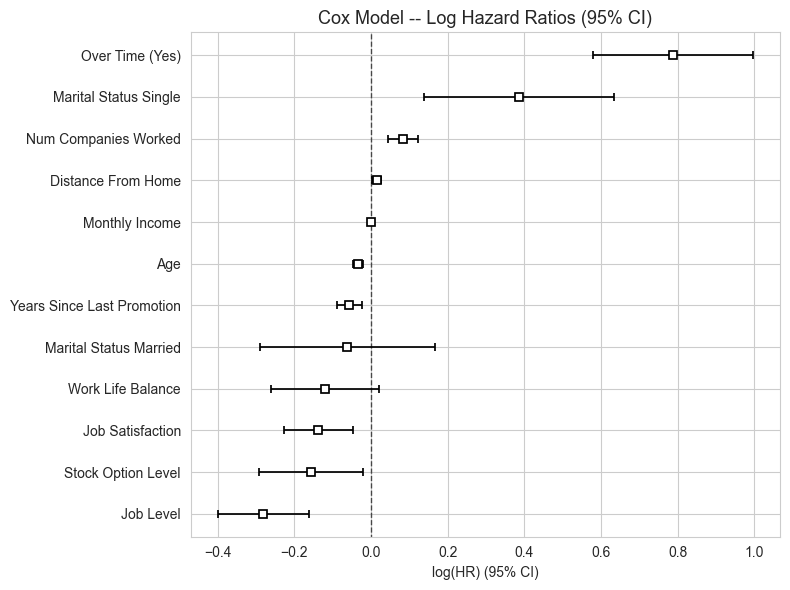


10 statistically significant factors (p < 0.05):


,exp(coef),p
covariate,,
Over Time (Yes),2.199,0.000
Age,0.968,0.000
Job Level,0.755,0.000
Num Companies Worked,1.087,0.000
Monthly Income,1.000,0.000
Years Since Last Promotion,0.945,0.001
Marital Status Single,1.471,0.002
Job Satisfaction,0.872,0.003
Distance From Home,1.015,0.015


In [8]:
cox_summary = cph.summary.sort_values("exp(coef)", ascending=False)
display(cox_summary[["coef", "exp(coef)", "p"]].round(3))

plt.figure(figsize=(8, 6))
cph.plot()
plt.title("Cox Model -- Log Hazard Ratios (95% CI)", fontsize=13)
plt.tight_layout()
cox_forest_path = os.path.join(FIG_DIR, "cox_hazard_ratios.png")
plt.savefig(cox_forest_path, dpi=300)
plt.show()

significant = cox_summary[cox_summary["p"] < 0.05].sort_values("p")
print(f"\n{len(significant)} statistically significant factors (p < 0.05):")
display(significant[["exp(coef)", "p"]].round(3))

## STEP 08 - Inference: Retention Curves

Overtime is checked here because it's confirmed significant above and is the most directly actionable of the significant factors.

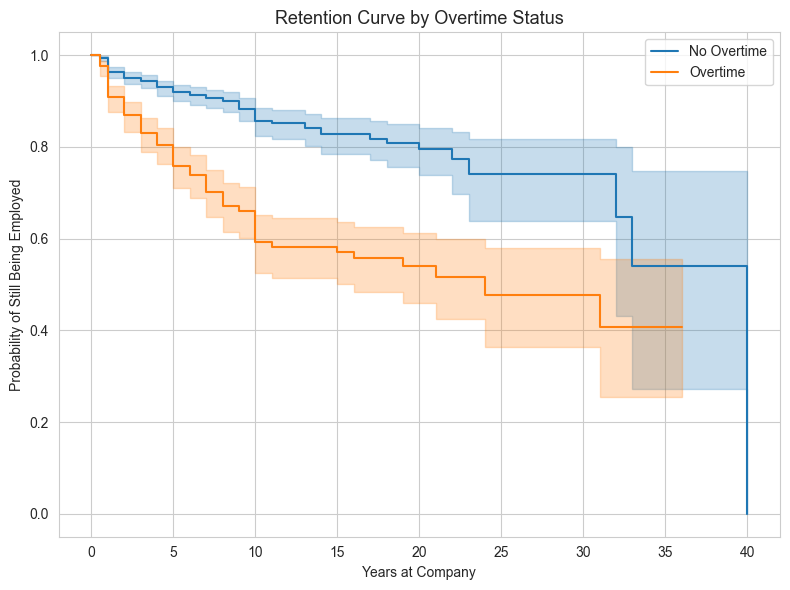

Log-rank test (Overtime vs No Overtime): p = 1.58e-19


In [9]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8, 6))
for label, mask in [("No Overtime", df["OverTime"] == "No"), ("Overtime", df["OverTime"] == "Yes")]:
    kmf.fit(
        durations=df.loc[mask, "YearsAtCompany"].clip(lower=0.5),
        event_observed=(df.loc[mask, "Attrition"] == "Yes").astype(int),
        label=label,
    )
    kmf.plot_survival_function(ax=ax)

plt.title("Retention Curve by Overtime Status", fontsize=13)
plt.xlabel("Years at Company")
plt.ylabel("Probability of Still Being Employed")
plt.tight_layout()
km_img_path = os.path.join(FIG_DIR, "km_overtime.png")
plt.savefig(km_img_path, dpi=300)
plt.show()

mask_ot = df["OverTime"] == "Yes"
lr = logrank_test(
    df.loc[mask_ot, "YearsAtCompany"], df.loc[~mask_ot, "YearsAtCompany"],
    event_observed_A=(df.loc[mask_ot, "Attrition"] == "Yes").astype(int),
    event_observed_B=(df.loc[~mask_ot, "Attrition"] == "Yes").astype(int),
)
print(f"Log-rank test (Overtime vs No Overtime): p = {lr.p_value:.2e}")

## STEP 09 - Forecasting: Rank Current Employees by Risk

`predict_partial_hazard` ranks relative risk; `predict_survival_function` at `t=1` converts that into something more directly usable -- the probability each employee leaves within the next year.

In [10]:
current = surv_df[surv_df["event"] == 0].copy()
current["Employee ID"] = EMPLOYEE_IDS.loc[current.index].values
current["Risk Score"] = cph.predict_partial_hazard(current)
current["Predicted Median Tenure (Years)"] = cph.predict_median(current)

survival_at_1y = cph.predict_survival_function(current, times=[1.0])
current["P(Leave within 1 Year)"] = 1 - survival_at_1y.loc[1.0]

at_risk = current.sort_values("Risk Score", ascending=False).head(15)
at_risk_display = at_risk[["Employee ID", "duration", "Risk Score", "P(Leave within 1 Year)", "Predicted Median Tenure (Years)"]].rename(
    columns={"duration": "Tenure So Far (Years)"}
)
display(at_risk_display.round(2))

,Employee ID,Tenure So Far (Years),Risk Score,P(Leave within 1 Year),Predicted Median Tenure (Years)
1436,2021,2.0,8.19,0.25,5.0
909,1269,1.0,8.02,0.25,5.0
841,1173,4.0,6.58,0.21,6.0
318,434,4.0,6.57,0.21,6.0
673,939,3.0,6.35,0.20,6.0
1137,1605,4.0,5.82,0.19,7.0
618,854,4.0,5.80,0.18,7.0
815,1131,2.0,5.73,0.18,7.0
931,1298,8.0,5.39,0.17,7.0
1122,1586,10.0,5.36,0.17,7.0


## STEP 10 - Forecasting: Risk Distribution Across All Current Employees

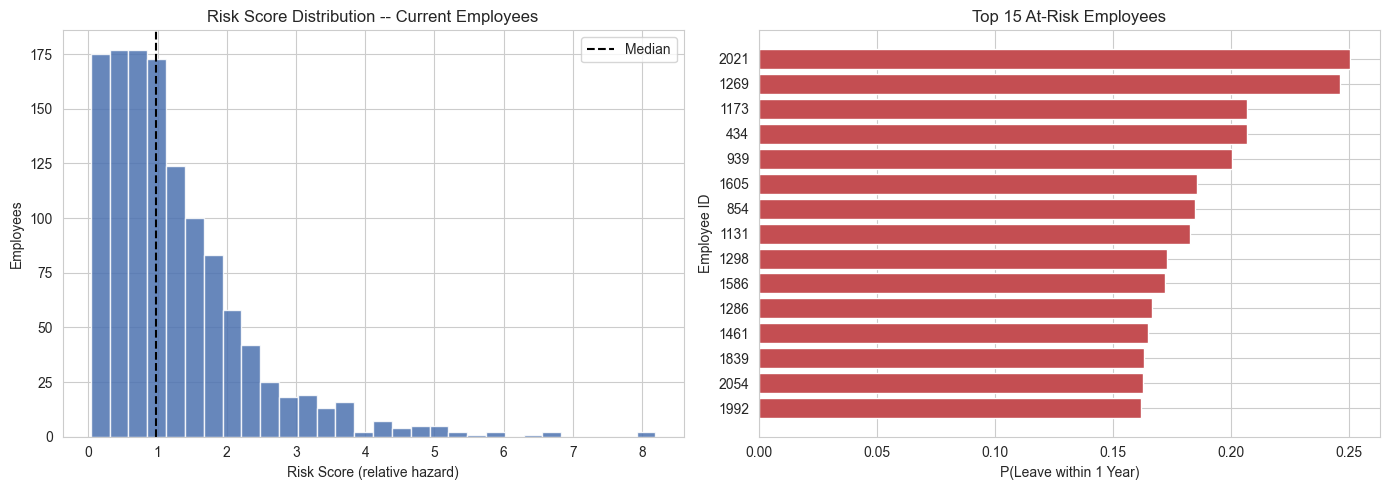

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(current["Risk Score"], bins=30, color="#4C72B0", alpha=0.85)
axes[0].axvline(current["Risk Score"].median(), color="black", linestyle="--", label="Median")
axes[0].set_title("Risk Score Distribution -- Current Employees")
axes[0].set_xlabel("Risk Score (relative hazard)")
axes[0].set_ylabel("Employees")
axes[0].legend()

top15 = at_risk.sort_values("P(Leave within 1 Year)")
axes[1].barh(top15["Employee ID"].astype(str), top15["P(Leave within 1 Year)"], color="#C44E52")
axes[1].set_title("Top 15 At-Risk Employees")
axes[1].set_xlabel("P(Leave within 1 Year)")
axes[1].set_ylabel("Employee ID")

plt.tight_layout()
risk_dist_path = os.path.join(FIG_DIR, "risk_distribution.png")
plt.savefig(risk_dist_path, dpi=300)
plt.show()

## STEP 11 - Build the Executive PowerPoint Report

Slide design (colors, type scale, cards, header/footer) lives in `report_builder.py`, reverse-engineered from a hand-refined version of this deck -- the notebook just imports it and hands it the numbers.

In [12]:
from report_builder import build_executive_report

report_path = build_executive_report(
    df, surv_df, current, at_risk, significant, test_cindex, cph_val, lr,
    cox_forest_path, km_img_path, risk_dist_path, output_dir=SLD_DIR,
)
print(f"Report saved to {report_path}")

Report saved to ../result/slides/Executive_Attrition_Report_20260830.pptx
